<a href="https://colab.research.google.com/github/ekomissarov/demos/blob/main/view_process_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import pm4py

rng = np.random.default_rng(42)

N_SESSIONS = 5000
rows = []

def add_event(session_id, event, timestamp):
    rows.append([session_id, event, timestamp])


for i in range(N_SESSIONS):
    session_id = f"s{i:05d}"
    t = pd.Timestamp("2026-01-01") + pd.Timedelta(
        seconds=int(rng.integers(0, 30 * 24 * 3600))
    )

    def event(name):
        global t
        add_event(session_id, name, t)
        t += pd.Timedelta(seconds=int(rng.integers(5, 120)))

    # ─────────────────────────────
    # Entry
    # ─────────────────────────────
    event("landing")

    # Different ways of starting the journey
    entry = rng.choice(
        ["search", "category", "recommendation"],
        p=[0.55, 0.25, 0.20]
    )
    event(entry)

    # ─────────────────────────────
    # Exploration
    # ─────────────────────────────
    event("product_view")

    # Some users compare several products
    n_extra_views = rng.choice(
        [0, 1, 2, 3],
        p=[0.50, 0.30, 0.15, 0.05]
    )

    for _ in range(n_extra_views):
        if rng.random() < 0.5:
            event("search")
        else:
            event("filter")

        event("product_view")

    # ─────────────────────────────
    # Wishlist / cart / exit
    # ─────────────────────────────
    action = rng.choice(
        ["cart", "wishlist", "exit"],
        p=[0.55, 0.20, 0.25]
    )
    event(action)

    if action == "exit":
        continue

    if action == "wishlist":
        # Some wishlist users leave immediately
        if rng.random() < 0.55:
            event("exit")
            continue

        # Others continue to cart
        event("cart")

    # ─────────────────────────────
    # Checkout
    # ─────────────────────────────
    if rng.random() < 0.15:
        event("remove_from_cart")
        event("exit")
        continue

    event("checkout")

    # Login can happen during checkout
    if rng.random() < 0.35:
        event("login")

    event("shipping")

    # Some users go back and change shipping
    if rng.random() < 0.12:
        event("change_shipping")
        event("shipping")

    event("payment")

    # ─────────────────────────────
    # Payment result
    # ─────────────────────────────
    if rng.random() < 0.12:
        event("payment_failed")

        # Some retry
        if rng.random() < 0.60:
            event("payment")
            event("purchase")
        else:
            event("exit")
    else:
        event("purchase")


df = pd.DataFrame(
    rows,
    columns=["session_id", "event", "timestamp"]
)

df



  Welcome to PM4Py — Community Version
  Open-Source License (AGPL v3)

  📚 Docs & Examples:
     https://processintelligence.solutions/pm4py

  ⚖️  License: AGPL v3 — Commercial use requires open-sourcing your application.
     Business use without open-sourcing? A commercial license is available:
     https://processintelligence.solutions/pm4py#licensing




,session_id,event,timestamp
0,s00000,landing,2026-01-03 16:15:38
1,s00000,search,2026-01-03 16:17:12
2,s00000,product_view,2026-01-03 16:18:06
3,s00000,search,2026-01-03 16:19:49
4,s00000,product_view,2026-01-03 16:20:54
...,...,...,...
42359,s04999,shipping,2026-01-28 14:20:06
42360,s04999,payment,2026-01-28 14:20:57
42361,s04999,payment_failed,2026-01-28 14:22:55
42362,s04999,payment,2026-01-28 14:23:20


In [ ]:
df = pm4py.format_dataframe(
    df,
    case_id="session_id",
    activity_key="event",
    timestamp_key="timestamp"
)

display(df.head(20))
print()
print("Events:", len(df))
print("Sessions:", df["case:concept:name"].nunique())

,session_id,event,timestamp,case:concept:name,concept:name,time:timestamp,@@index,@@case_index
0,s00000,landing,2026-01-03 16:15:38+00:00,s00000,landing,2026-01-03 16:15:38+00:00,0,0
1,s00000,search,2026-01-03 16:17:12+00:00,s00000,search,2026-01-03 16:17:12+00:00,1,0
2,s00000,product_view,2026-01-03 16:18:06+00:00,s00000,product_view,2026-01-03 16:18:06+00:00,2,0
3,s00000,search,2026-01-03 16:19:49+00:00,s00000,search,2026-01-03 16:19:49+00:00,3,0
4,s00000,product_view,2026-01-03 16:20:54+00:00,s00000,product_view,2026-01-03 16:20:54+00:00,4,0
5,s00000,exit,2026-01-03 16:22:51+00:00,s00000,exit,2026-01-03 16:22:51+00:00,5,0
6,s00001,landing,2026-01-24 13:57:58+00:00,s00001,landing,2026-01-24 13:57:58+00:00,6,1
7,s00001,search,2026-01-24 13:59:02+00:00,s00001,search,2026-01-24 13:59:02+00:00,7,1
8,s00001,product_view,2026-01-24 13:59:21+00:00,s00001,product_view,2026-01-24 13:59:21+00:00,8,1
9,s00001,filter,2026-01-24 14:00:23+00:00,s00001,filter,2026-01-24 14:00:23+00:00,9,1



Events: 42364
Sessions: 5000


In [ ]:
variants = pm4py.get_variants_as_tuples(df)

for variant, count in variants.items():
    print(count, variant)

115 ('landing', 'search', 'product_view', 'search', 'product_view', 'exit')
14 ('landing', 'search', 'product_view', 'filter', 'product_view', 'search', 'product_view', 'wishlist', 'exit')
1 ('landing', 'category', 'product_view', 'filter', 'product_view', 'search', 'product_view', 'search', 'product_view', 'wishlist', 'cart', 'checkout', 'shipping', 'payment', 'purchase')
1 ('landing', 'category', 'product_view', 'filter', 'product_view', 'filter', 'product_view', 'cart', 'checkout', 'login', 'shipping', 'change_shipping', 'shipping', 'payment', 'purchase')
316 ('landing', 'search', 'product_view', 'cart', 'checkout', 'shipping', 'payment', 'purchase')
179 ('landing', 'search', 'product_view', 'cart', 'checkout', 'login', 'shipping', 'payment', 'purchase')
148 ('landing', 'category', 'product_view', 'exit')
348 ('landing', 'search', 'product_view', 'exit')
40 ('landing', 'search', 'product_view', 'filter', 'product_view', 'cart', 'remove_from_cart', 'exit')
28 ('landing', 'category', 

In [ ]:
variants = pm4py.get_variants_as_tuples(df)

print("Number of variants:", len(variants))

top_variants = sorted(
    variants.items(),
    key=lambda x: x[1],
    reverse=True
)[:10]

for variant, count in top_variants:
    print(count, " → ".join(variant))

Number of variants: 457
348 landing → search → product_view → exit
316 landing → search → product_view → cart → checkout → shipping → payment → purchase
179 landing → search → product_view → cart → checkout → login → shipping → payment → purchase
157 landing → search → product_view → wishlist → exit
152 landing → category → product_view → cart → checkout → shipping → payment → purchase
148 landing → category → product_view → exit
131 landing → recommendation → product_view → exit
130 landing → recommendation → product_view → cart → checkout → shipping → payment → purchase
127 landing → search → product_view → cart → remove_from_cart → exit
115 landing → search → product_view → search → product_view → exit


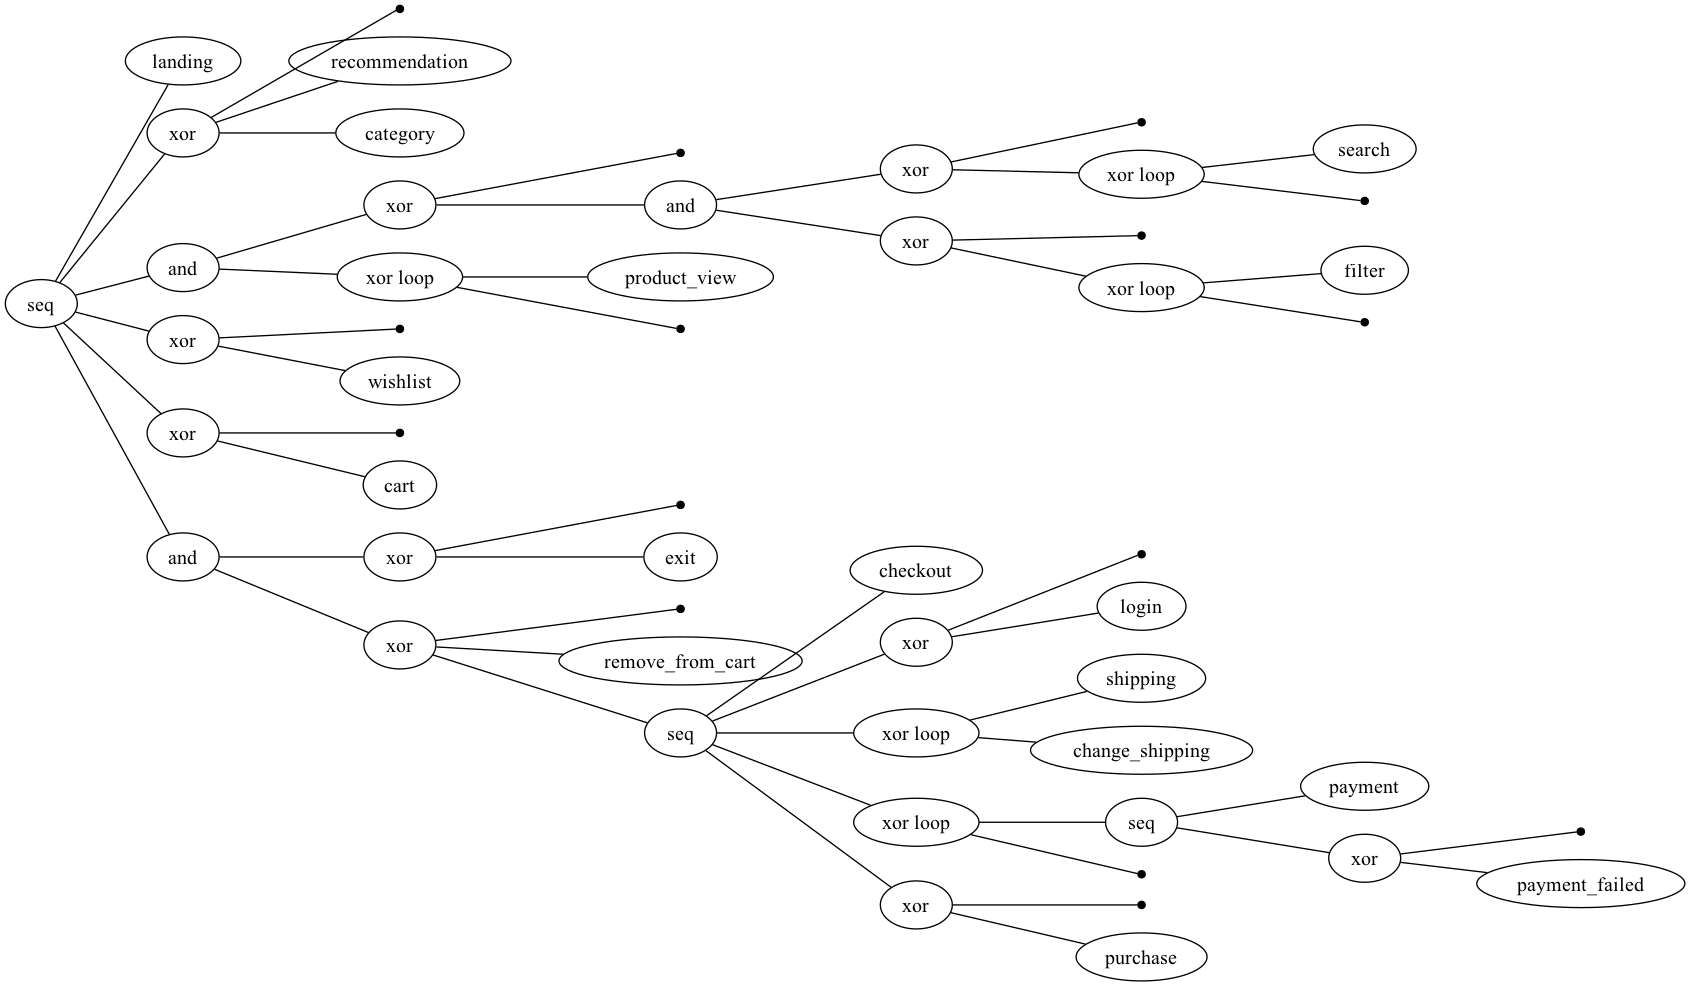

In [ ]:
tree = pm4py.discover_process_tree_inductive(df)
pm4py.view_process_tree(tree)

# Как читать Process Tree в PM4Py

Главное — **не воспринимать Process Tree как обычный flowchart**.  
Это формальное дерево, которое нужно читать **от корня и рекурсивно разбирать его ветви**.

---

## Основные обозначения

### `seq` — Sequence

Последовательное выполнение:

`SEQ(A, B, C)`

означает:

> Сначала A → затем B → затем C.

---

### `xor` — Exclusive Choice

Выбирается **одна из ветвей**:

`XOR(A, B, C)`

означает:

> Происходит либо A, либо B, либо C.

Например:

`XOR(search, category, recommendation)`

означает, что пользователь продолжил journey через один из этих вариантов.

---

### `and` — Parallel

Все ветви должны выполниться, но их порядок не фиксирован:

`AND(A, B)`

допускает:

- A → B
- B → A

`AND` **не обязательно означает физически одновременные события**.

Он означает, что алгоритм не обнаружил строгого порядка между этими действиями.

---

### `xor loop` — Loop

Описывает повторяющуюся часть процесса.

Например, пользователь может делать:

`product_view → search → product_view → search → product_view`

или:

`product_view → filter → product_view`

Inductive Miner может представить такую структуру через `xor loop`.

Это особенно полезно для обнаружения повторяющихся паттернов поведения.

---

### `●` — Silent transition (`tau`)

Чёрная точка означает:

> Ничего не делать / пропустить эту ветку.

Например:

`XOR(login, ●)`

означает:

> `login` является опциональным.

А:

`XOR(purchase, ●)`

означает:

> `purchase` может произойти, а может отсутствовать.

В исходном event log события `●` не существует. Оно добавляется самой моделью.

---

# Как читать дерево

Самый левый `seq` — **корень Process Tree**.

Упрощённо всё дерево можно представить как:

    SEQ(
        landing,
        entry,
        exploration,
        cart/wishlist,
        checkout,
        payment
    )

Каждый из этих элементов сам может быть поддеревом.

Например:

    SEQ(
        landing,

        XOR(
            search,
            category,
            recommendation
        ),

        product_view,

        XOR(
            purchase,
            exit
        )
    )

Человеческим языком это читается так:

> Сначала пользователь попадает на landing.  
> Затем он продолжает через search, category или recommendation.  
> Затем смотрит продукт.  
> После этого либо совершает purchase, либо выходит.

---

# Почему дерево выглядит как набор «столбцов»

Это особенность визуализации дерева.

Graphviz располагает узлы так, чтобы большая структура помещалась на экране и линии меньше пересекались.

Поэтому **вертикальное положение узлов не означает время**.

Порядок процесса определяется структурой дерева и прежде всего операторами `seq`.

---

# Пример из нашего synthetic event log

В генераторе было:

    landing
       ↓
    search / category / recommendation
       ↓
    product_view

Поэтому Inductive Miner обнаружил примерно:

    SEQ(
        landing,

        XOR(
            search,
            category,
            recommendation
        ),

        product_view
    )

Мы **не сообщали PM4Py эту структуру напрямую**.

Inductive Miner получил только event log и сам восстановил эту закономерность.

---

# Exploration loop

В генераторе мы также специально заложили повторное исследование товаров:

    product_view
         ↓
    search / filter
         ↓
    product_view
         ↓
    search / filter
         ↓
    product_view
         ...

Поэтому Process Tree обнаружил `xor loop`.

Это пример того, как process mining позволяет автоматически обнаруживать **повторяющиеся behavioral patterns**.

---

# Как интерпретировать `AND`

Если в event log встречаются:

    A → B
    A → B
    B → A
    A → B
    B → A

Inductive Miner может построить:

    AND(A, B)

То есть:

> Оба события являются частью процесса, но строгого порядка между ними модель не обнаружила.

Поэтому некоторые `AND` в реальном Process Tree могут выглядеть немного странно с точки зрения бизнес-логики.

Алгоритм восстанавливает модель **из наблюдаемых traces**, а не знает смысл событий.

---

# Нижняя часть нашего процесса

На высоком уровне она соответствует примерно такой логике:

    checkout
        ↓
    [optional login]
        ↓
    shipping
        ↓
    [possible change_shipping / repetition]
        ↓
    payment
        ↓
    purchase / payment_failed / exit

Но Process Tree представляет эту логику формально через комбинацию:

- `SEQ`
- `XOR`
- `AND`
- `LOOP`
- `τ`

---

# Главное

Process Tree можно воспринимать как своеобразное **регулярное выражение для пользовательского journey**.

Например:

    SEQ(
        landing,

        XOR(
            search,
            category,
            recommendation
        ),

        LOOP(
            product_view,
            XOR(search, filter)
        ),

        XOR(
            purchase,
            exit
        )
    )

описывает целое множество допустимых пользовательских путей.

Поэтому полезная ментальная модель:

**Event Log → Traces → Inductive Miner → Process Tree → структура пользовательского поведения**

Не нужно сразу пытаться понять всё большое дерево целиком.

Лучше брать небольшое поддерево и мысленно переводить его в:

`SEQ(...)`, `XOR(...)`, `AND(...)` или `LOOP(...)`.

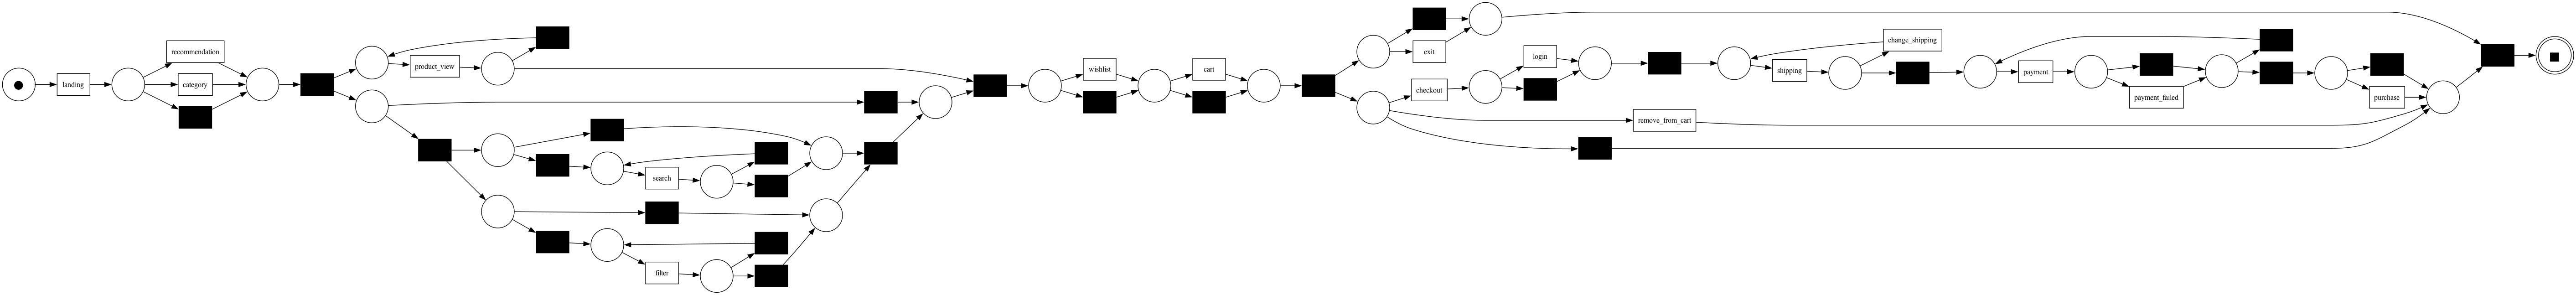

In [ ]:
net, initial_marking, final_marking = \
    pm4py.discover_petri_net_inductive(df)

pm4py.view_petri_net(
    net,
    initial_marking,
    final_marking
)

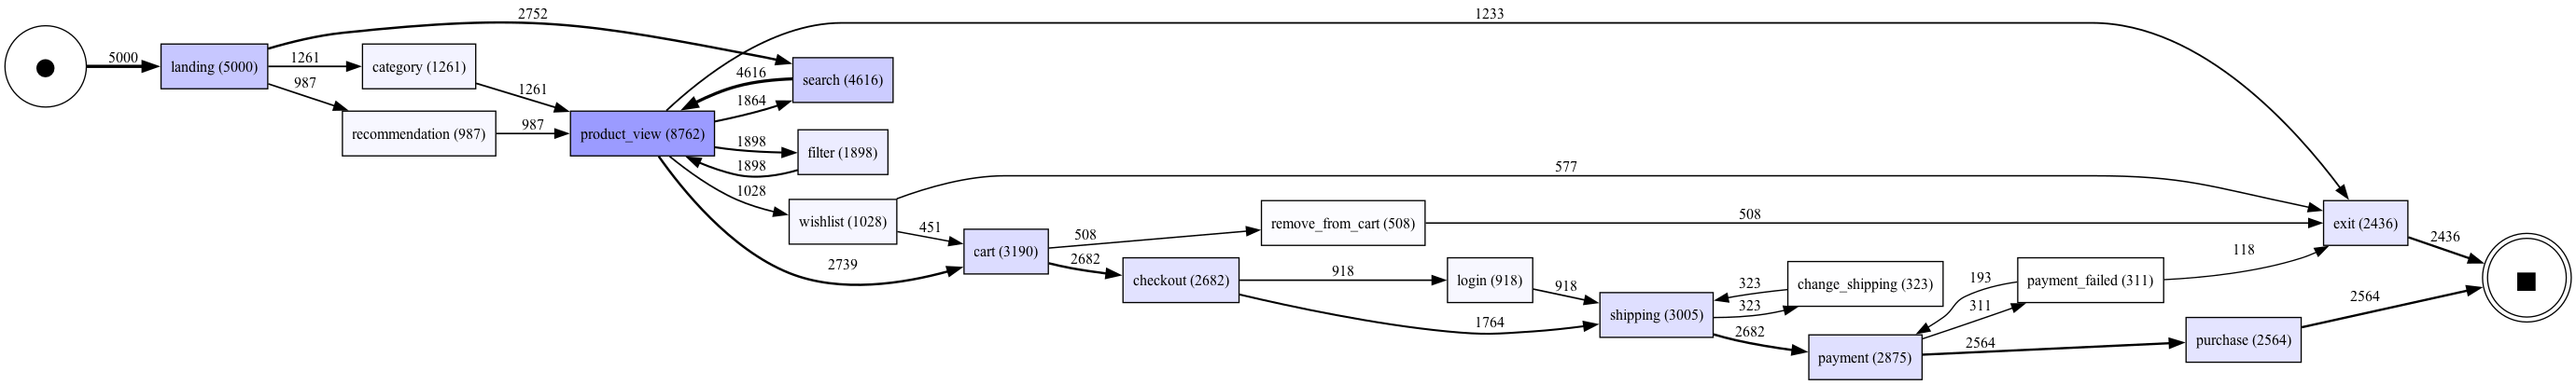

In [ ]:
dfg, start, end = pm4py.discover_dfg(df)

pm4py.view_dfg(
    dfg,
    start,
    end
)